# Chapter 11. Time Series
- Many time series are **fixed frequency**, which is to say that data points occur at regular intervals according to some rule.
> - **Timestamps:** Specific instants in time.
> - **Fixed periods:** Such as the whole month of January 2017, or the whole year 2020.
> - **Intervals of time:** Indicated by start and end timestamp. Periods can be thought of as special cases of intervals.
> - **Experiment or elapsed time:** Each timestamp is a measure of time relative to a particular start time.
- Many of the techniques can be applied to experimental time series where the **index may be an integer or floating-point number** indicating elapsed time from the start of the experiment.
- Pandas also **supports indexes based on timedeltas**, which can be a useful way of representing experiment or elaspsed time.

In [4]:
import numpy as np
import pandas as pd

In [5]:
from datetime import datetime

In [6]:
from datetime import timedelta

## 11.1 Date and Time Data Types and Tools
- Calendar-related functionality
- The ***datetime***, ***time***, and ***calendar*** modules are the main places to start.
- ***datetime*** stores both the date and time down to the microsecond.

In [4]:
now = datetime.now()
now

datetime.datetime(2022, 12, 11, 8, 28, 10, 204933)

In [5]:
now.year, now.month, now.day

(2022, 12, 11)

> - ***datetime.timedelta***, or simply ***timedelta***, represents **the temporal difference** between two datetime objects:

In [15]:
delta = datetime(2011,1,7) - datetime(2008, 6, 24, 8, 15)

In [16]:
delta

datetime.timedelta(days=926, seconds=56700)

In [19]:
delta.seconds

56700

In [21]:
start = datetime(2011, 1, 7)

In [22]:
start + timedelta(12)

datetime.datetime(2011, 1, 19, 0, 0)

> 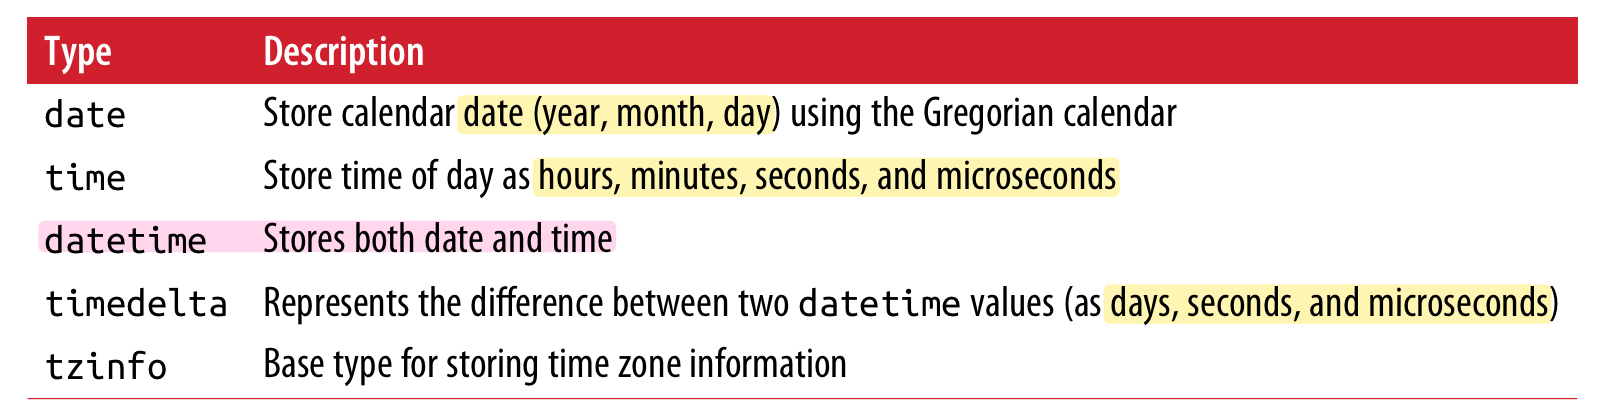

### Converting Between String and Datetime
- You can format ***datetime*** object and pandas ***Timestamp*** objects, **as string using *str*** or the ***strftime*** method
- ***datetime*** objects also have **a number of locale-specific formatting options** for systems in other countries or languages.

In [7]:
stamp = datetime(2011, 1, 3)
str(stamp)

'2011-01-03 00:00:00'

In [8]:
stamp.strftime('%Y-%m-%d')

'2011-01-03'

> 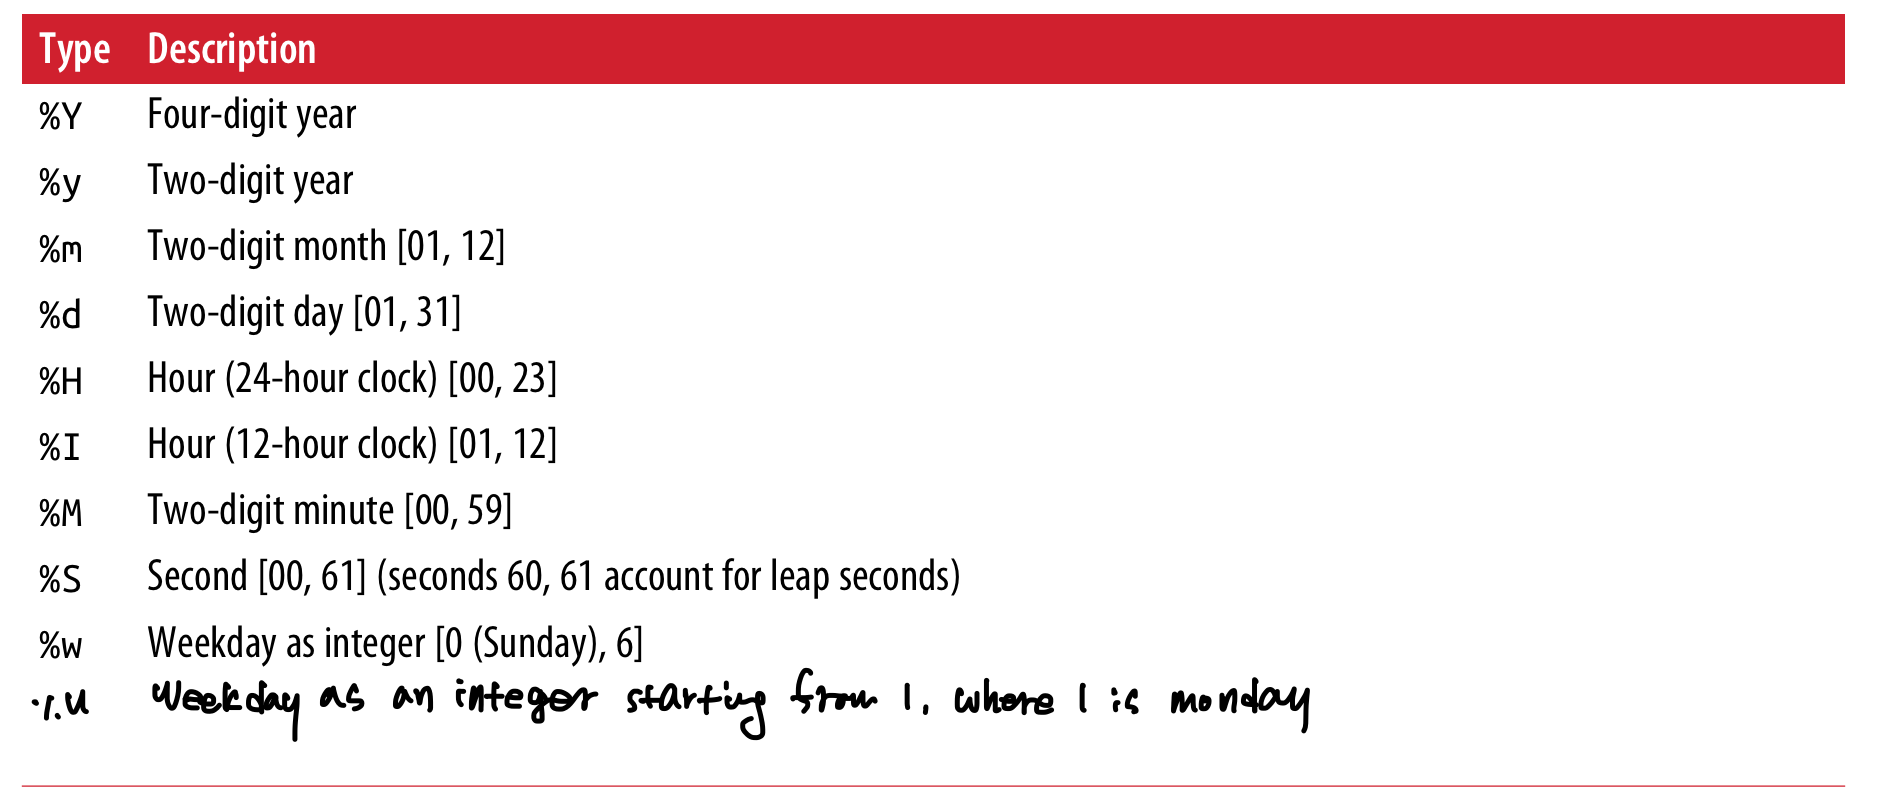
> 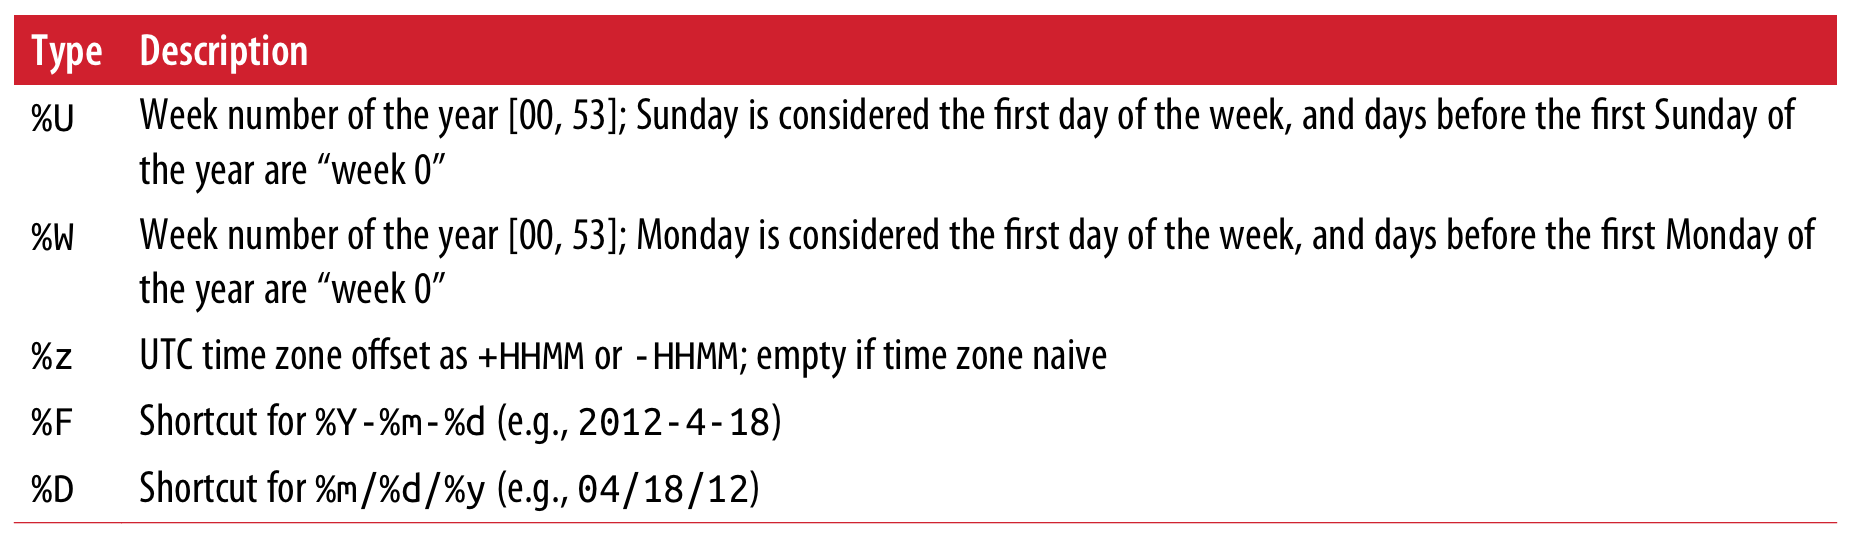

> - To convert strings to dates using ***datetime.strptime***:
> - ***datetime.strptime*** is one way to parse a date with a known format.

In [9]:
value = '2011-01-03'
datetime.strptime(value, '%Y-%m-%d')

datetime.datetime(2011, 1, 3, 0, 0)

In [7]:
datestrs = ['7/6/2011','8/6/2011']
[datetime.strptime(x, '%m/%d/%Y') for x in datestrs]

[datetime.datetime(2011, 7, 6, 0, 0), datetime.datetime(2011, 8, 6, 0, 0)]

> - The ***pandas.to_datetime*** method parses many different kinds of date representations.
> - Standard date formats like ISO8601 can be parsed quickly:

In [4]:
datestrs = ['2011-07-06 12:00:00', '2011-08-06 00:00:00']
pd.to_datetime(datestrs)

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[ns]', freq=None)

## 11.2 Time Series Basics
- A basic kind of time series object in pandas is **a Series indexed by timestamps**, which is often represented outside of pandas as **Python strings** or **datetime** objects:
- pandas stores **timestamps** using **NumPy's *datetime64 data type*** at the **nanosecond resolution**:
- *pandas.Timestamp* can store **nanosecond precision** data, while *datetime* stores only up to **microseconds**.

In [12]:
dates = [datetime(2011,1,2), datetime(2011,1,5), datetime(2011,1,7),
         datetime(2011,1,8), datetime(2011,1,10), datetime(2011,1,12)]

In [13]:
ts = pd.Series(np.random.standard_normal(6), index=dates)
ts

2011-01-02   -0.134158
2011-01-05   -1.236499
2011-01-07   -1.673548
2011-01-08    0.343299
2011-01-10    0.405174
2011-01-12   -0.461747
dtype: float64

In [14]:
ts.index

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[ns]', freq=None)

> - Like ohter Series, **arithmetic operations** between differently indexed time series **automatically align on the dates**:

In [15]:
ts[::2]

2011-01-02   -0.134158
2011-01-07   -1.673548
2011-01-10    0.405174
dtype: float64

In [16]:
ts + ts[::2]

2011-01-02   -0.268316
2011-01-05         NaN
2011-01-07   -3.347096
2011-01-08         NaN
2011-01-10    0.810348
2011-01-12         NaN
dtype: float64

### Indexing, Selection, Subsetting
- Time series behaves like any other Series when you are indexing and selecting data based on the label.
- For longer time series, a year or only a year and month can be passed to easily select slices of data:
- Slicing produces **views on the source time series**, like slicing NumPy arrays. This means that **no data is copied**, and modifications on the slice will **be reflected in the original data**.

In [7]:
longer_ts = pd.Series(np.random.standard_normal(1000),
                      index=pd.date_range('2000-01-01', periods=1000))

In [8]:
longer_ts

2000-01-01    1.338227
2000-01-02    0.268089
2000-01-03   -1.324582
2000-01-04    0.178234
2000-01-05   -0.434225
                ...   
2002-09-22   -0.001697
2002-09-23    1.530709
2002-09-24   -1.314540
2002-09-25   -0.488967
2002-09-26    0.294343
Freq: D, Length: 1000, dtype: float64

In [9]:
# year
longer_ts['2001']

2001-01-01    1.050233
2001-01-02   -1.576300
2001-01-03    0.643252
2001-01-04   -0.788497
2001-01-05    1.244979
                ...   
2001-12-27   -0.465799
2001-12-28    0.585343
2001-12-29   -0.294020
2001-12-30    0.166966
2001-12-31    0.494721
Freq: D, Length: 365, dtype: float64

In [10]:
# month
longer_ts['2001-05']

2001-05-01    0.200331
2001-05-02   -0.383527
2001-05-03   -0.897222
2001-05-04    0.109591
2001-05-05    0.605594
2001-05-06    0.574415
2001-05-07   -0.873245
2001-05-08   -0.021491
2001-05-09   -1.102808
2001-05-10    0.986663
2001-05-11    1.067551
2001-05-12    1.430319
2001-05-13    0.566345
2001-05-14    0.638352
2001-05-15    0.674294
2001-05-16   -1.776132
2001-05-17   -0.251759
2001-05-18    2.059699
2001-05-19    1.495056
2001-05-20    1.160094
2001-05-21    0.168710
2001-05-22   -0.241854
2001-05-23    0.772413
2001-05-24   -1.640615
2001-05-25   -0.147755
2001-05-26    0.674881
2001-05-27   -0.836134
2001-05-28   -0.289780
2001-05-29    0.820730
2001-05-30    2.529848
2001-05-31   -1.271429
Freq: D, dtype: float64

> - Slicing with *datetime* objects works as well:

In [17]:
ts[datetime(2011,1,7):]

2011-01-07   -1.673548
2011-01-08    0.343299
2011-01-10    0.405174
2011-01-12   -0.461747
dtype: float64

In [18]:
ts[datetime(2011,1,7):datetime(2011,1,10)]

2011-01-07   -1.673548
2011-01-08    0.343299
2011-01-10    0.405174
dtype: float64

> - Because most time series data is ordered chronologically, you can **slice with timestamps not contained in a time series** to perform a range query:

In [16]:
ts

2011-01-02    0.723339
2011-01-05   -2.000323
2011-01-07   -0.764858
2011-01-08    1.885756
2011-01-10   -0.824073
2011-01-12    0.736807
dtype: float64

In [17]:
ts['2011-01-06':'2011-01-11']

2011-01-07   -0.764858
2011-01-08    1.885756
2011-01-10   -0.824073
dtype: float64

> - There is an equivalent instance method, ***truncate***, that slices a Series between two dates:

In [18]:
ts.truncate(after='2011-01-09')

2011-01-02    0.723339
2011-01-05   -2.000323
2011-01-07   -0.764858
2011-01-08    1.885756
dtype: float64

### Time Series with Duplicate Indices

In [22]:
dates = pd.DatetimeIndex(['2000-01-01', '2000-01-02', '2000-01-02', '2000-01-02', '2000-01-03'])

In [24]:
dup_ts = pd.Series(np.arange(5), index=dates)
dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int64

> - The index is not unique by **checking its *is_unique* property**:
> - Indexing into this time series will now either produces scalar values or slices, depending on **whether a timestamp is duplicated**:

In [25]:
dup_ts['2000-01-03'] # not duplicated

4

In [26]:
dup_ts['2000-01-02'] # duplicated

2000-01-02    1
2000-01-02    2
2000-01-02    3
dtype: int64

> - Suppose you wanted to aggregate the data having nonunique timestamps. One way to do is to use *groupby* and pass ***level=0*** (the one and only level

In [27]:
grouped = dup_ts.groupby(level=0)

In [28]:
grouped.mean()

2000-01-01    0.0
2000-01-02    2.0
2000-01-03    4.0
dtype: float64

In [29]:
grouped.count()

2000-01-01    1
2000-01-02    3
2000-01-03    1
dtype: int64